# PatchTST OHLCV forecasting -- HF PatchTSTModel replication of steven's task

**Updated**: swapped the head from a flattened/fused joint projection to a true
channel-independent head (matching the official PatchTST paper's `individual=False`
design, cross-checked against an external MQL5-article implementation) -- see the "Model"
section below for what changed and why. Checkpoint renamed to
`patchtst_true_headindep_checkpoint.pt` so the earlier fused-head result stays available
for comparison.

`steven/src/models/patchtst.py` is a hand-rolled PatchTST-style transformer: it patches
the input (7-bar / 1-trading-day patches) and self-attends across patches, but does
**early channel fusion** -- all 7 feature channels are flattened together into one linear
patch embedding before any attention happens. It does not use the paper's channel-independence
design, and has no way to toggle channel-mixing on/off.

This notebook replicates steven's exact **task** (same data, same target parameterization,
same loss) with the real HF `PatchTSTModel` backbone instead, which *does* implement
channel-independent patching (each channel patched/embedded separately) with an optional
`channel_attention` sublayer to let channels cross-inform each other. That gives us a lever
steven's architecture structurally can't offer: toggle `CHANNEL_ATTENTION` below and rerun to
compare channel-independent vs. channel-mixing on the identical task/loss/data.

**Kept identical to steven's setup, for a fair comparison:**
- Data: `steven/data/spy_ohlcv_1h.parquet`, same train/val/test date splits (`steven/src/data_pipeline.py`).
- Target parameterization: anchored log-returns per horizon bar (`open_ret`, `body_ret`,
  `upper_wick`, `lower_wick`) + `log_volume_norm`, 3 bars ahead (`HORIZON=3`), reused directly
  from `steven/src/data_pipeline.py`/`steven/src/losses.py` (`build_dataset`, `unpack_y`,
  `weighted_mse_loss`, `reconstruct_prices`, `reconstruct_volume`) -- no reimplementation.
- Loss: the same deterministic weighted MSE (`w_price=1.0`, `w_vol=0.5`), same bounded output
  (`tanh`/`sigmoid` x `MAX_LOG_RETURN`) applied to the head's raw output before the loss --
  this notebook's model produces the exact same 15-dim output shape/bounding as steven's, so
  `weighted_mse_loss`/`unpack_y` are reused unmodified.
- Patch structure: `patch_length=7`, `patch_stride=7` (non-overlapping, one trading day per
  patch), matching steven's `PATCH_LEN=7`.
- Training hyperparameters: `lr=6e-4`, `weight_decay=1e-4`, `batch_size=512`, 20 epochs x
  20,000 resampled windows/epoch -- from `steven/configs/patchtst.yaml`.

**One deliberate simplification**: steven's model trains on a variable-context curriculum
(2-10 trading days, resampled per window). HF `PatchTSTModel` patchifies a single fixed
`context_length` per model, so this notebook fixes `context_length=MAX_CONTEXT=70` (10 trading
days, steven's longest curriculum option) rather than replicating the curriculum -- most
directly comparable to steven's own "long" context bucket in `steven/outputs/metrics.json`,
not his "overall" (mixed-length) numbers.

**Deferred**: the long-only limit-order backtest (`steven/src/evaluate.py`'s `run_backtest`)
is not implemented here -- per instruction, that comes after we've confirmed which
architecture/`channel_attention` setting is actually better on the forecasting metrics.</cell id="516f1f85">


## Colab setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB


In [2]:
import os

REPO_URL = "https://github.com/WoodyChang21/ECE1508_GenAI.git"
BRANCH = "PatchTST_OLCV"
REPO_DIR = "/content/ECE1508_GenAI"   # absolute path -- see note below

if not os.path.isdir(REPO_DIR):
    !git clone -b {BRANCH} {REPO_URL} {REPO_DIR}
else:
    # git -C targets REPO_DIR explicitly rather than `cd X && ...`, so this is correct
    # regardless of the kernel's current working directory when the cell reruns.
    !git -C {REPO_DIR} pull

# Absolute path, not "ECE1508_GenAI": os.path.isdir("ECE1508_GenAI") above is checked
# relative to the CURRENT working directory -- on a second run of this cell (after the
# %cd below already moved the kernel into /content/ECE1508_GenAI), that relative check
# looks for /content/ECE1508_GenAI/ECE1508_GenAI, finds nothing, and silently clones a
# second, nested copy of the repo inside the first one instead of pulling it.
%cd {REPO_DIR}

Already up to date.
/content/ECE1508_GenAI


In [3]:
# torch is preinstalled on Colab; transformers is the one addition vs. steven's own
# colab_train.ipynb (steven's hand-rolled model has no library dependency for this).
!pip install -q transformers mplfinance pyyaml

In [4]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## Imports and config

`sys.path` is set up so `from src.data_pipeline import ...` / `from src.losses import ...`
resolve the same way steven's own scripts import them (both insert `steven/` itself onto
the path, not the repo root -- see `steven/src/train_patchtst.py`).

In [5]:
import sys, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from transformers import PatchTSTConfig, PatchTSTModel

# Normalise cwd to the repo root regardless of whether this notebook is opened from
# within steven/ (local Jupyter) or the repo root (Colab, after the clone cell above).
if os.path.basename(os.getcwd()) == 'steven':
    os.chdir('..')
sys.path.insert(0, 'steven')

from src.data_pipeline import (
    build_dataset, extract_arrays, WindowSampler, build_window,
    reconstruct_prices, reconstruct_volume,
    MAX_CONTEXT, HORIZON, N_FEATURE_CHANNELS, MAX_LOG_RETURN,
)
from src.losses import weighted_mse_loss, unpack_y

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

DATA_PATH = 'steven/data/spy_ohlcv_1h.parquet'

# -- Toggle this and rerun to compare channel-independent vs. channel-mixing on the
# identical task/loss/data -- the whole point of replicating steven's task with HF
# PatchTSTModel instead of his early-channel-fusion architecture.
CHANNEL_ATTENTION = True

# -- Model hyperparameters -- matched to steven/configs/patchtst.yaml's model block
# (d_model, nhead->num_attention_heads, num_layers->num_hidden_layers, dropout) so
# model capacity is comparable, not just the loss function.
D_MODEL      = 64
NUM_HEADS    = 4
NUM_LAYERS   = 3
DROPOUT      = 0.1
HEAD_DROPOUT = 0.0

# -- Patch structure -- matches steven's PATCH_LEN=7 (one trading day, non-overlapping).
PATCH_LEN    = 7
PATCH_STRIDE = 7

# -- Training hyperparameters -- from steven/configs/patchtst.yaml, unchanged.
LR                      = 6e-4
WEIGHT_DECAY            = 1e-4
BATCH_SIZE              = 512
MAX_EPOCHS              = 20
TRAIN_WINDOWS_PER_EPOCH = 20000
WINDOWS_PER_EVAL_SET    = 3000

# -- Loss weights -- from steven/configs/patchtst.yaml's loss block, unchanged.
W_PRICE = 1.0
W_VOL   = 0.5

plt.rcParams['figure.figsize'] = (14, 4)

# -- Seed control --------------------------------------------------------
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'SEED = {SEED}, CHANNEL_ATTENTION = {CHANNEL_ATTENTION}')

Device: cuda
SEED = 0, CHANNEL_ATTENTION = True


## Model

`PatchTSTModel` backbone (HF's real channel-independent-or-mixing encoder) + a
**true channel-independent head** -- the same `nn.Linear(d_model, HORIZON)` weights are
applied to each of the 5 forecastable channels' own pooled representation independently,
with no flattening/concatenation across channels anywhere in the head. This matches the
official PatchTST paper's `individual=False` head design (verified against an external
MQL5-article implementation and the paper itself -- see `docs/experiments.md`): the same
weights are *reused* per channel, but each channel's forecast is built only from its own
encoder output.

**Changed from the previous version of this notebook**: the original head instead flattened
all 5 channels into one vector before a single joint projection
(`self.head = nn.Linear(5 * d_model, 15)`), which reintroduced cross-channel mixing at the
head *regardless* of the `channel_attention` setting -- meaning the earlier
`channel_attention=True` vs `False` comparison only ever isolated *encoder*-level mixing,
with head-level fusion present in both. This version isolates `channel_attention` cleanly:
with the encoder's cross-channel sublayer on, this is now the *only* cross-channel pathway
in the model.

Same bounded output (`tanh`/`sigmoid` x `MAX_LOG_RETURN`) as before, applied per-channel
after the head instead of after a joint projection, so `weighted_mse_loss`/`unpack_y` from
`steven/src/losses.py` still work unmodified.

`scaling=None`: steven's model has no per-window instance normalization (his
`open_ret`/`body_ret`/wicks are raw log-returns, and `log_volume_norm` is already
globally normalized once via train-split stats in `data_pipeline.py`). Also verified
against the HF source directly: `PatchTSTStdScaler` is a non-learnable RevIN-lite
(mean/std normalize only, no `affine_weight`/`affine_bias` -- the real RevIN paper's
defining feature) -- disabled here regardless, so the comparison is about the encoder/head
architecture, not confounded by an extra normalization layer only one side has.

Only channels 0-4 (`open_ret`, `body_ret`, `upper_wick`, `lower_wick`,
`log_volume_norm`) are ever forecast -- channels 5/6 (`time_gap_norm`,
`day_bar_index_norm`) are context-only inputs, matching steven's `PRICE_VOL_IDX`
restriction (his `y` target never includes them either).</cell id="96064ec5">


In [6]:
class PatchTSTOHLCV(nn.Module):
    def __init__(self, config: PatchTSTConfig):
        super().__init__()
        self.backbone = PatchTSTModel(config)
        # True channel-independent head: this SAME nn.Linear(d_model, HORIZON) is applied to
        # every one of the 5 forecastable channels' own pooled representation independently
        # (nn.Linear broadcasts over the middle dim of a (bs, 5, d_model) input) -- no
        # flattening/concatenation across channels anywhere. Matches the official PatchTST
        # paper's individual=False head design.
        self.head = nn.Linear(config.d_model, HORIZON)
        self.dropout = nn.Dropout(config.head_dropout)

    def forward(self, past_values: torch.Tensor):
        base_out = self.backbone(past_values=past_values)
        pooled = base_out.last_hidden_state.mean(dim=2)      # mean-pool across patches: (bs, 7, d_model)
        pooled = self.dropout(pooled[:, :5, :])                # only the 5 forecastable channels: (bs, 5, d_model)
        raw = self.head(pooled)                                 # same weights per channel: (bs, 5, HORIZON)

        # raw[:, c, :] is channel c's own HORIZON-bar forecast, built only from that channel's
        # own pooled representation -- channels 0-3 are price components, channel 4 is volume.
        open_ret   = MAX_LOG_RETURN * torch.tanh(raw[:, 0, :])
        body_ret   = MAX_LOG_RETURN * torch.tanh(raw[:, 1, :])
        upper_wick = MAX_LOG_RETURN * torch.sigmoid(raw[:, 2, :])
        lower_wick = MAX_LOG_RETURN * torch.sigmoid(raw[:, 3, :])
        price = torch.stack([open_ret, body_ret, upper_wick, lower_wick], dim=-1)   # (bs, HORIZON, 4)

        volume = raw[:, 4, :]   # (bs, HORIZON)
        return price, volume


def build_model() -> PatchTSTOHLCV:
    config = PatchTSTConfig(
        num_input_channels=N_FEATURE_CHANNELS,   # 7
        context_length=MAX_CONTEXT,              # 70 (fixed -- see markdown above)
        prediction_length=HORIZON,               # 3
        patch_length=PATCH_LEN,
        patch_stride=PATCH_STRIDE,
        d_model=D_MODEL,
        num_attention_heads=NUM_HEADS,
        num_hidden_layers=NUM_LAYERS,
        dropout=DROPOUT,
        head_dropout=HEAD_DROPOUT,
        channel_attention=CHANNEL_ATTENTION,
        scaling=None,   # see markdown above -- steven's model has no per-window normalization
    )
    return PatchTSTOHLCV(config)

## Data

Reuses `build_dataset`/`extract_arrays`/`WindowSampler`/`build_window` from
`steven/src/data_pipeline.py` unmodified -- same feature engineering, same
chronological train/val/test split boundaries as steven's own training run.

In [7]:
df, bounds, stats = build_dataset(DATA_PATH)
feat, opens, closes = extract_arrays(df)

train_sampler = WindowSampler(*bounds['train'])
val_sampler   = WindowSampler(*bounds['val'])
test_sampler  = WindowSampler(*bounds['test'])

print(f'Train rows: {bounds["train"][1] - bounds["train"][0]:,}')
print(f'Val rows  : {bounds["val"][1] - bounds["val"][0]:,}')
print(f'Test rows : {bounds["test"][1] - bounds["test"][0]:,}')


class FixedContextDataset(Dataset):
    """
    Same window construction as steven's WindowDataset (build_window), but every
    window uses the full MAX_CONTEXT (70 bars) -- see the fixed-context caveat in
    the intro markdown. Since ctx_bars == MAX_CONTEXT exactly, build_window's
    padding is always zero-length, so no padding_mask handling is needed here.
    """
    def __init__(self, feat: np.ndarray, opens: np.ndarray, closes: np.ndarray, start_indices: np.ndarray):
        self.feat, self.opens, self.closes = feat, opens, closes
        self.start_indices = start_indices

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, i):
        w = build_window(self.feat, self.opens, self.closes, int(self.start_indices[i]), MAX_CONTEXT)
        context = w['masked_tensor'][:MAX_CONTEXT, :N_FEATURE_CHANNELS]
        return {
            'past_values': torch.from_numpy(context),
            'y': torch.from_numpy(w['y']),
            'close_0': w['close_0'],
        }


def collate(batch: list[dict]) -> dict:
    return {
        'past_values': torch.stack([b['past_values'] for b in batch]),
        'y': torch.stack([b['y'] for b in batch]),
        'close_0': np.array([b['close_0'] for b in batch]),
    }

Train rows: 21,042
Val rows  : 3,495
Test rows : 2,469


## Training

In [8]:
def run_epoch(model, loader, optimizer, device, train: bool, loss_history=None, step_holder=None, log_every=10):
    model.train(mode=train)
    total, price_total, vol_total, n = 0.0, 0.0, 0.0, 0
    for batch in loader:
        past_values = batch['past_values'].to(device)
        y = batch['y'].to(device)

        with torch.set_grad_enabled(train):
            price, volume = model(past_values)
            loss, parts = weighted_mse_loss(price, volume, y, W_PRICE, W_VOL)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if step_holder is not None:
                step_holder[0] += 1
                if loss_history is not None and (step_holder[0] == 1 or step_holder[0] % log_every == 0):
                    loss_history.append((step_holder[0], float(loss.item())))

        bs = y.shape[0]
        total += loss.item() * bs
        price_total += parts['price_loss'] * bs
        vol_total += parts['vol_loss'] * bs
        n += bs
    return {'loss': total / n, 'price_loss': price_total / n, 'vol_loss': vol_total / n}

In [9]:
train_starts_full = train_sampler.valid_starts(MAX_CONTEXT)
val_starts_full    = val_sampler.valid_starts(MAX_CONTEXT)
print(f'Valid train starts (ctx=70): {len(train_starts_full):,}')
print(f'Valid val starts (ctx=70)  : {len(val_starts_full):,}')

val_rng = np.random.default_rng(SEED)
n_val = min(WINDOWS_PER_EVAL_SET, len(val_starts_full))
val_starts = val_rng.choice(val_starts_full, size=n_val, replace=False)
val_ds = FixedContextDataset(feat, opens, closes, val_starts)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

model = build_model().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Saved on every val-loss improvement, matching steven/src/train_patchtst.py's own
# checkpointing behaviour -- the .pt always holds the best-val-loss epoch's weights,
# not necessarily the final epoch's. 'config' is saved alongside the weights so a
# later evaluate/backtest script can rebuild the exact same architecture before
# loading state_dict, same pattern steven's own checkpoints use.
# '_headindep' suffix: this is the true channel-independent head, not the earlier
# flattened/fused head -- kept as a separate file so both remain comparable
# (evaluate.py's derive_output_suffix picks up the whole 'true_headindep' token).
CKPT_PATH = 'steven/outputs/patchtst_true_headindep_checkpoint.pt'
os.makedirs('steven/outputs', exist_ok=True)

loss_history = []
step_holder = [0]
best_val_loss = float('inf')

for epoch in range(MAX_EPOCHS):
    train_rng = np.random.default_rng(SEED + epoch)
    n_train = min(TRAIN_WINDOWS_PER_EPOCH, len(train_starts_full))
    train_starts = train_rng.choice(train_starts_full, size=n_train, replace=False)
    train_ds = FixedContextDataset(feat, opens, closes, train_starts)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

    train_metrics = run_epoch(model, train_loader, optimizer, DEVICE, train=True,
                               loss_history=loss_history, step_holder=step_holder)
    val_metrics = run_epoch(model, val_loader, optimizer, DEVICE, train=False)

    print(f'epoch {epoch+1:2d}/{MAX_EPOCHS}  '
          f'train_loss={train_metrics["loss"]:.5f} (price={train_metrics["price_loss"]:.5f}, vol={train_metrics["vol_loss"]:.5f})  '
          f'val_loss={val_metrics["loss"]:.5f} (price={val_metrics["price_loss"]:.5f}, vol={val_metrics["vol_loss"]:.5f})')

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save({
            'model_state': model.state_dict(),
            'config': {
                'model': {
                    'd_model': D_MODEL,
                    'num_attention_heads': NUM_HEADS,
                    'num_hidden_layers': NUM_LAYERS,
                    'dropout': DROPOUT,
                    'head_dropout': HEAD_DROPOUT,
                    'channel_attention': CHANNEL_ATTENTION,
                    'patch_length': PATCH_LEN,
                    'patch_stride': PATCH_STRIDE,
                },
                'context_length': MAX_CONTEXT,
                'data_path': DATA_PATH,
                'seed': SEED,
            },
        }, CKPT_PATH)
        print(f'  -> saved best checkpoint (val_loss={best_val_loss:.5f}) to {CKPT_PATH}')

print(f'\ndone. best val_loss={best_val_loss:.5f}, checkpoint={CKPT_PATH}')

Valid train starts (ctx=70): 20,970
Valid val starts (ctx=70)  : 3,423
epoch  1/20  train_loss=0.22091 (price=0.00282, vol=0.43619)  val_loss=0.18341 (price=0.00278, vol=0.36128)
  -> saved best checkpoint (val_loss=0.18341) to steven/outputs/patchtst_true_headindep_checkpoint.pt
epoch  2/20  train_loss=0.16992 (price=0.00278, vol=0.33427)  val_loss=0.10575 (price=0.00274, vol=0.20602)
  -> saved best checkpoint (val_loss=0.10575) to steven/outputs/patchtst_true_headindep_checkpoint.pt
epoch  3/20  train_loss=0.14715 (price=0.00293, vol=0.28844)  val_loss=0.09833 (price=0.00306, vol=0.19053)
  -> saved best checkpoint (val_loss=0.09833) to steven/outputs/patchtst_true_headindep_checkpoint.pt
epoch  4/20  train_loss=0.14022 (price=0.00302, vol=0.27440)  val_loss=0.09706 (price=0.00302, vol=0.18808)
  -> saved best checkpoint (val_loss=0.09706) to steven/outputs/patchtst_true_headindep_checkpoint.pt
epoch  5/20  train_loss=0.13941 (price=0.00312, vol=0.27259)  val_loss=0.09750 (price=0.0

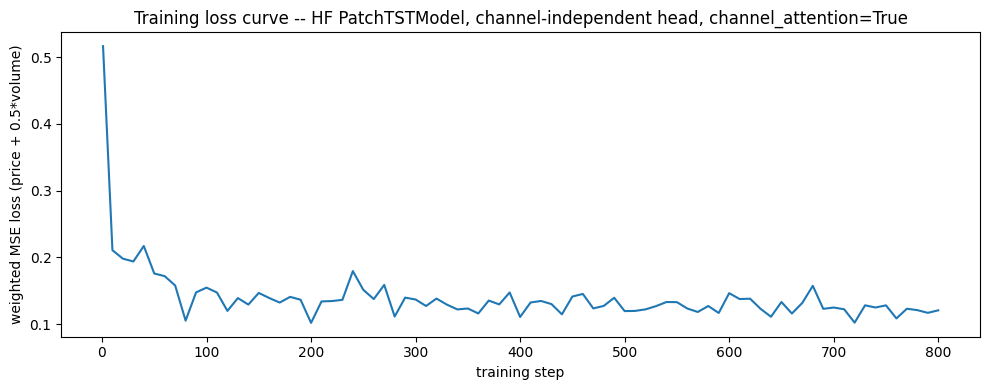

In [10]:
# -- Training loss curve ------------------------------------------
steps, losses = zip(*loss_history)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, losses)
ax.set_xlabel('training step')
ax.set_ylabel('weighted MSE loss (price + 0.5*volume)')
ax.set_title(f'Training loss curve -- HF PatchTSTModel, channel-independent head, channel_attention={CHANNEL_ATTENTION}')
plt.tight_layout()
plt.show()

## Evaluation

Same methodology as `steven/src/evaluate.py`'s `metrics_for_slice`: reparam-space
MAE/RMSE (the raw 15-dim vector), reconstructed OHLC MAE/RMSE (via
`reconstruct_prices`), volume MAE/RMSE (via `reconstruct_volume`), and per-horizon-bar
directional accuracy on the close_0-anchored close return
(`open_ret + body_ret`, sign match). Same test seed (`123`) as `evaluate.py`'s default,
so the sampled test windows are reproducible the same way.

**Comparability note**: this model only supports `context_length=70` (steven's "long"
bucket), not his full variable-length curriculum -- so compare against steven's **long**
bucket numbers below, not his "overall" (mixed-length) numbers.

In [11]:
def mae_rmse(pred: np.ndarray, true: np.ndarray) -> tuple[float, float]:
    diff = pred - true
    return float(np.mean(np.abs(diff))), float(np.sqrt(np.mean(diff ** 2)))


test_starts_full = test_sampler.valid_starts(MAX_CONTEXT)
test_rng = np.random.default_rng(123)   # matches steven/src/evaluate.py's --seed default
n_test = min(3000, len(test_starts_full))
test_starts = test_rng.choice(test_starts_full, size=n_test, replace=False)
test_ds = FixedContextDataset(feat, opens, closes, test_starts)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)

model.eval()
all_true_y, all_pred_y, all_close0 = [], [], []
with torch.no_grad():
    for batch in test_loader:
        pv = batch['past_values'].to(DEVICE)
        price, volume = model(pv)
        pred_y = torch.cat([price.reshape(price.shape[0], -1), volume], dim=1)
        all_true_y.append(batch['y'].numpy())
        all_pred_y.append(pred_y.cpu().numpy())
        all_close0.append(batch['close_0'])

true_y = np.concatenate(all_true_y)
pred_y = np.concatenate(all_pred_y)
close_0 = np.concatenate(all_close0)
n = len(true_y)
print(f'Evaluated on {n:,} fixed-context (70-bar) test windows')

reparam_mae, reparam_rmse = mae_rmse(pred_y, true_y)

true_price = true_y[:, :12].reshape(n, 3, 4)
pred_price = pred_y[:, :12].reshape(n, 3, 4)
true_ohlc = reconstruct_prices(true_price, close_0)
pred_ohlc = reconstruct_prices(pred_price, close_0)
ohlc_mae, ohlc_rmse = mae_rmse(pred_ohlc, true_ohlc)

true_vol_norm = true_y[:, 12:15]
pred_vol_norm = pred_y[:, 12:15]
true_vol = reconstruct_volume(true_vol_norm, stats)
pred_vol = reconstruct_volume(pred_vol_norm, stats)
vol_mae, vol_rmse = mae_rmse(pred_vol, true_vol)

true_close_ret = true_price[:, :, 0] + true_price[:, :, 1]
pred_close_ret = pred_price[:, :, 0] + pred_price[:, :, 1]
dir_acc = (np.sign(pred_close_ret) == np.sign(true_close_ret)).mean(axis=0)

print(f'\n=== HF PatchTSTModel, channel-independent head, channel_attention={CHANNEL_ATTENTION}, context=70 (fixed) ===')
print(f'  reparam MAE / RMSE : {reparam_mae:.5f} / {reparam_rmse:.5f}')
print(f'  OHLC MAE / RMSE    : {ohlc_mae:.4f} / {ohlc_rmse:.4f}')
print(f'  volume MAE / RMSE  : {vol_mae:,.1f} / {vol_rmse:,.1f}')
print(f'  dir acc per bar    : {dir_acc[0]:.4f} / {dir_acc[1]:.4f} / {dir_acc[2]:.4f}')

print('\n=== For comparison: fused (flattened) head, channel_attention=True, commit a7d38ec ===')
print('  reparam MAE / RMSE : 0.11786 / 0.49865')
print('  OHLC MAE / RMSE    : 3.3845 / 4.5144')
print('  volume MAE / RMSE  : 3,280,981.5 / 16,198,569.0')
print('  dir acc per bar    : 0.5315 / 0.5403 / 0.5544')

print('\n=== For comparison: steven/outputs/metrics.json, original hand-rolled PatchTST, "long" bucket ===')
print('  reparam MAE / RMSE : 0.22700 / 0.64267')
print('  OHLC MAE / RMSE    : 11.2096 / 13.7618')
print('  volume MAE / RMSE  : 5,234,852.5 / 6,398,097.0')
print('  dir acc per bar    : 0.5075 / 0.5285 / 0.5405')

Evaluated on 2,397 fixed-context (70-bar) test windows

=== HF PatchTSTModel, channel-independent head, channel_attention=True, context=70 (fixed) ===
  reparam MAE / RMSE : 0.15416 / 0.45225
  OHLC MAE / RMSE    : 38.4216 / 50.7093
  volume MAE / RMSE  : 2,132,328.8 / 3,800,277.2
  dir acc per bar    : 0.4935 / 0.5031 / 0.4827

=== For comparison: fused (flattened) head, channel_attention=True, commit a7d38ec ===
  reparam MAE / RMSE : 0.11786 / 0.49865
  OHLC MAE / RMSE    : 3.3845 / 4.5144
  volume MAE / RMSE  : 3,280,981.5 / 16,198,569.0
  dir acc per bar    : 0.5315 / 0.5403 / 0.5544

=== For comparison: steven/outputs/metrics.json, original hand-rolled PatchTST, "long" bucket ===
  reparam MAE / RMSE : 0.22700 / 0.64267
  OHLC MAE / RMSE    : 11.2096 / 13.7618
  volume MAE / RMSE  : 5,234,852.5 / 6,398,097.0
  dir acc per bar    : 0.5075 / 0.5285 / 0.5405


## Caveats and recommended next steps

- **This is now a true channel-independent-except-`channel_attention` model.** With the
  fused/flattened head replaced (see "Model" markdown above), the encoder's
  `channel_attention` sublayer is now the *only* cross-channel pathway in the model when
  `True`. Compare its metrics against the earlier fused-head `channel_attention=True` run
  (commit `a7d38ec`, printed above) to see whether head-level fusion was doing anything
  useful, and against the sibling `channel_attention=False` notebook to isolate what the
  encoder's cross-channel sublayer alone contributes.
- **One seed, one trained model.** Rerun with a different `SEED` before trusting any
  specific delta.
- **Fixed context (70 bars) vs. steven's variable-length curriculum.** Compare against
  steven's "long" bucket, not "overall".
- **`evaluate.py` does NOT support this checkpoint yet.** `src/models/patchtst_hf.py`'s
  `PatchTSTHF` class still has the old fused head -- loading
  `patchtst_true_headindep_checkpoint.pt`'s `state_dict` into it will fail with a shape
  mismatch on the head's weights (`(15, 320)` fused vs. `(3, 64)` channel-independent).
  `PatchTSTHF` needs updating to this same channel-independent head (and `evaluate.py`'s
  `detect_patchtst_arch` may need a way to distinguish the two HF head variants, e.g. a
  `head_type` field in the saved config) before the backtest can run on this variant --
  not done in this pass, notebook-only per instruction.
- **Series decomposition (trend/residual split) is still not implemented** -- the other
  gap identified against the MQL5-article comparison, not addressed in this pass.</cell id="8b87fc95">
